In [1]:
# ============================================================
# Step 7 setup: read Step 6 JSON
#
# This script visualizes an existing Step 6 output JSON.
# It does not require rerunning Step 6.
#
# Compatible with:
#   - Setting B3 direct/direct:  test_direct_only
#   - Setting B3 inverse/inverse: test_inverse_only
# ============================================================

import os
import json
import math
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from google.colab import drive
drive.mount("/content/drive")

# ------------------------------------------------------------
# 1. Set Step 6 JSON path
# ------------------------------------------------------------

json_path = Path(
    "/content/drive/MyDrive/Colab Notebooks/linear_probe_pilot4/expA_settingB_6fps/settingB3/data/pilot4_p4_expA_settingB3_2_step6.json"
    )

# ------------------------------------------------------------
# 2. Output directory
# ------------------------------------------------------------

output_dir = Path("/content/step7_pilot4_settingB3_figures")
output_dir.mkdir(parents=True, exist_ok=True)

print("Step 6 JSON exists:", json_path.exists())
print("Step 6 JSON path:", json_path)
print("Output dir:", output_dir)

if not json_path.exists():
    raise FileNotFoundError(f"Step 6 JSON not found: {json_path}")

with open(json_path, "r", encoding="utf-8") as f:
    data = json.load(f)

print("\nLoaded Step 6 JSON.")
print("Top-level keys:")
print(list(data.keys()))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Step 6 JSON exists: True
Step 6 JSON path: /content/drive/MyDrive/Colab Notebooks/linear_probe_pilot4/expA_settingB_6fps/settingB3/data/pilot4_p4_expA_settingB3_2_step6.json
Output dir: /content/step7_pilot4_settingB3_figures

Loaded Step 6 JSON.
Top-level keys:
['experiment_name', 'description', 'model_name', 'model_tag', 'feature_key', 'label_field', 'num_samples_loaded', 'num_layers', 'feature_dim', 'label_order', 'scene_split_info', 'test_subset_summary', 'step6_config', 'source_pt_files', 'results_by_layer']


In [2]:
# ============================================================
# Basic metadata and structure checks
# ============================================================

experiment_name = data.get("experiment_name", "unknown_experiment")
model_tag = data.get("model_tag", "unknown_model")
feature_key = data.get("feature_key", "unknown_feature")

results_by_layer = data.get("results_by_layer", [])

if not results_by_layer:
    raise ValueError("No results_by_layer found in Step 6 JSON.")

# ------------------------------------------------------------
# Automatically detect test subset keys.
#
# For Setting B3 same-direction outputs, this will usually be:
#   test_direct_only
# or:
#   test_inverse_only
# ------------------------------------------------------------

subset_keys = [
    key for key in results_by_layer[0].keys()
    if key not in {"layer", "train"}
]

if not subset_keys:
    raise ValueError("No test subset keys found in results_by_layer[0].")

label_order = data.get("label_order")

if label_order is None:
    label_order = results_by_layer[0][subset_keys[0]]["label_order"]

num_layers = data.get("num_layers", len(results_by_layer))
scene_split_info = data.get("scene_split_info", {})
test_subset_summary = data.get("test_subset_summary", {})
step6_config = data.get("step6_config", {})

print("Experiment:", experiment_name)
print("Model:", model_tag)
print("Feature:", feature_key)
print("Num layers:", num_layers)
print("Labels:", label_order)
print("Detected test subset keys:", subset_keys)

print("\nStep 6 description:")
print(data.get("description", ""))

print("\nStep 6 config:")
print(json.dumps(step6_config, indent=2, ensure_ascii=False))

print("\nTrain direction filter info:")
print(json.dumps(scene_split_info.get("train_direction_filter_info", {}), indent=2, ensure_ascii=False))

print("\nTest direction filter info:")
print(json.dumps(scene_split_info.get("test_direction_filter_info", {}), indent=2, ensure_ascii=False))

print("\nTest subset summary:")
print(json.dumps(test_subset_summary, indent=2, ensure_ascii=False))

# ------------------------------------------------------------
# Required keys check
# ------------------------------------------------------------

for layer_result in results_by_layer:
    if "train" not in layer_result:
        raise KeyError(f"Missing train result in layer {layer_result.get('layer')}")

    for subset_key in subset_keys:
        if subset_key not in layer_result:
            raise KeyError(f"Missing subset {subset_key} in layer {layer_result.get('layer')}")

        for key in ["accuracy", "macro_f1", "classification_report", "confusion_matrix", "label_order"]:
            if key not in layer_result[subset_key]:
                raise KeyError(
                    f"Missing key {key} in {subset_key}, layer {layer_result.get('layer')}"
                )

print("\nStructure check passed.")

Experiment: settingB3_2_scene_split_train_inverse_test_inverse
Model: Qwen2_5_3B
Feature: layer_diff_features
Num layers: 37
Labels: ['above', 'below', 'contains', 'in', 'left_of', 'near', 'on', 'right_of', 'supports']
Detected test subset keys: ['test_inverse_only']

Step 6 description:
Setting B3 same-direction scene-split evaluation. Training uses only inverse samples from train scenes. Testing uses only inverse samples from test scenes. Scene split is preserved.

Step 6 config:
{
  "setting": "B3_same_direction_scene_split",
  "experiment_name": "settingB3_2_scene_split_train_inverse_test_inverse",
  "direction_filter_protocol": "same_direction",
  "model_name": "Qwen/Qwen2.5-3B",
  "model_tag": "Qwen2_5_3B",
  "feature_key": "layer_diff_features",
  "label_field": "relation",
  "train_scenes": [
    "FloorPlan1",
    "FloorPlan2",
    "FloorPlan3",
    "FloorPlan4"
  ],
  "test_scenes": [
    "FloorPlan5",
    "FloorPlan6"
  ],
  "filter_train_by_direction": true,
  "filter_test_b

In [3]:
# ============================================================
# Build layer-wise dataframe
# ============================================================

def build_layerwise_dataframe(data, subset_keys):
    rows = []

    for layer_result in data["results_by_layer"]:
        layer = int(layer_result["layer"])

        row = {
            "layer": layer,
            "train_accuracy": layer_result["train"]["accuracy"],
            "train_macro_f1": layer_result["train"]["macro_f1"],
        }

        for subset_key in subset_keys:
            row[f"{subset_key}_accuracy"] = layer_result[subset_key]["accuracy"]
            row[f"{subset_key}_macro_f1"] = layer_result[subset_key]["macro_f1"]
            row[f"{subset_key}_num_examples"] = layer_result[subset_key]["num_examples"]

        rows.append(row)

    return pd.DataFrame(rows)


layerwise_df = build_layerwise_dataframe(data, subset_keys)

csv_path = output_dir / f"step7_{experiment_name}_{model_tag}_{feature_key}_layerwise_metrics.csv"
layerwise_df.to_csv(csv_path, index=False)

print("Saved layerwise metrics:")
print(csv_path)

display(layerwise_df.head())

Saved layerwise metrics:
/content/step7_pilot4_settingB3_figures/step7_settingB3_2_scene_split_train_inverse_test_inverse_Qwen2_5_3B_layer_diff_features_layerwise_metrics.csv


,layer,train_accuracy,train_macro_f1,test_inverse_only_accuracy,test_inverse_only_macro_f1,test_inverse_only_num_examples
0,0,0.671381,0.442504,0.447761,0.303800,670
1,1,1.000000,1.000000,0.788060,0.708787,670
2,2,1.000000,1.000000,0.886567,0.845595,670
3,3,1.000000,1.000000,0.889552,0.846721,670
4,4,1.000000,1.000000,0.870149,0.833030,670


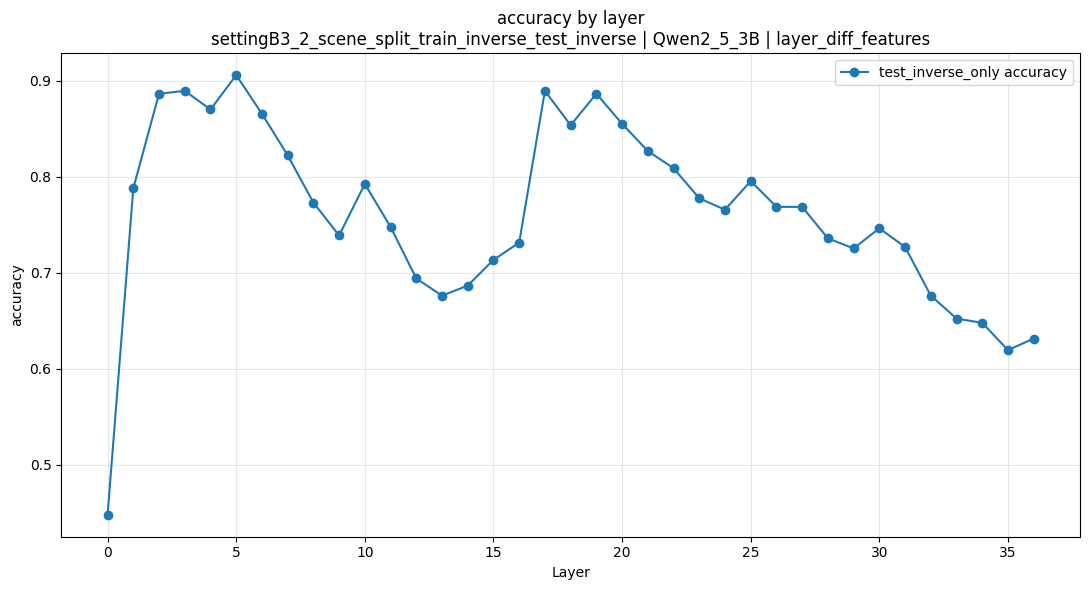

Saved: /content/step7_pilot4_settingB3_figures/step7_settingB3_2_scene_split_train_inverse_test_inverse_Qwen2_5_3B_layer_diff_features_layerwise_accuracy.png


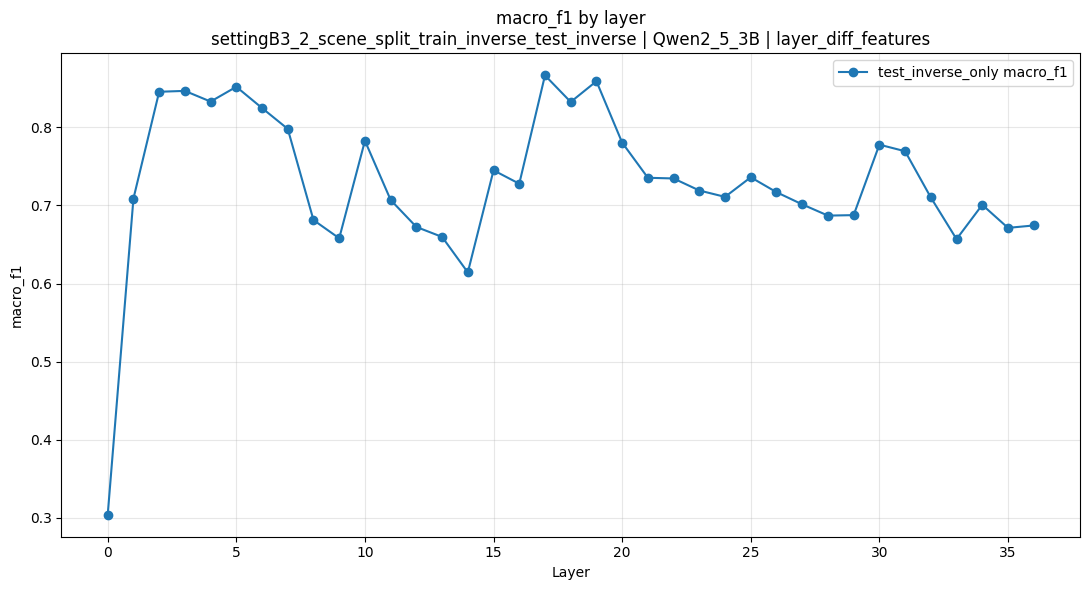

Saved: /content/step7_pilot4_settingB3_figures/step7_settingB3_2_scene_split_train_inverse_test_inverse_Qwen2_5_3B_layer_diff_features_layerwise_macro_f1.png


In [4]:
# ============================================================
# Plot layer-wise accuracy / macro-F1 curves
# ============================================================

def plot_layerwise_metric_curves(df, metric_name, output_dir, subset_keys):
    """
    metric_name:
      "accuracy" or "macro_f1"
    """

    plt.figure(figsize=(11, 6))

    for subset_key in subset_keys:
        plt.plot(
            df["layer"],
            df[f"{subset_key}_{metric_name}"],
            marker="o",
            label=f"{subset_key} {metric_name}",
        )

    plt.xlabel("Layer")
    plt.ylabel(metric_name)
    plt.title(
        f"{metric_name} by layer\n"
        f"{experiment_name} | {model_tag} | {feature_key}"
    )
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()

    fig_path = output_dir / f"step7_{experiment_name}_{model_tag}_{feature_key}_layerwise_{metric_name}.png"
    plt.savefig(fig_path, dpi=200)
    plt.show()

    print("Saved:", fig_path)


plot_layerwise_metric_curves(layerwise_df, "accuracy", output_dir, subset_keys)
plot_layerwise_metric_curves(layerwise_df, "macro_f1", output_dir, subset_keys)

In [5]:
# ============================================================
# Skip direct-minus-inverse gap for single Setting B3 output
# ============================================================

print("Skipping direct-minus-inverse gap plot.")

print(
    "Reason: this Step 6 JSON contains only one test subset:",
    subset_keys,
)

print(
    "For Setting B3, direct-vs-inverse comparison should be done by loading "
    "two separate Step 6 JSON files, e.g. one direct/direct run and one inverse/inverse run."
)

Skipping direct-minus-inverse gap plot.
Reason: this Step 6 JSON contains only one test subset: ['test_inverse_only']
For Setting B3, direct-vs-inverse comparison should be done by loading two separate Step 6 JSON files, e.g. one direct/direct run and one inverse/inverse run.


In [6]:
# ============================================================
# Build per-class metric heatmap dataframes
# ============================================================

def build_per_class_metric_dataframe(data, subset_key, labels, metric):
    """
    metric:
      "precision", "recall", or "f1-score"
    """

    rows = []

    for layer_result in data["results_by_layer"]:
        layer = int(layer_result["layer"])
        report = layer_result[subset_key]["classification_report"]

        row = {"layer": layer}

        for label in labels:
            row[label] = float(report.get(label, {}).get(metric, 0.0))

        rows.append(row)

    df = pd.DataFrame(rows).set_index("layer")
    return df


per_class_dfs = {}

for subset_key in subset_keys:
    per_class_dfs[(subset_key, "precision")] = build_per_class_metric_dataframe(
        data, subset_key, label_order, "precision"
    )
    per_class_dfs[(subset_key, "recall")] = build_per_class_metric_dataframe(
        data, subset_key, label_order, "recall"
    )
    per_class_dfs[(subset_key, "f1")] = build_per_class_metric_dataframe(
        data, subset_key, label_order, "f1-score"
    )

example_subset_key = subset_keys[0]

print(f"Example: {example_subset_key} recall dataframe")
display(per_class_dfs[(example_subset_key, "recall")].head())

Example: test_inverse_only recall dataframe


,above,below,contains,in,left_of,near,on,right_of,supports
layer,,,,,,,,,
0,0.101695,0.013699,0.0,0.0,0.380952,0.000000,0.932203,0.515528,0.947917
1,0.762712,0.657534,1.0,0.0,0.678571,0.804348,0.983051,0.788820,1.000000
2,0.932203,0.739726,1.0,0.4,0.845238,0.913043,0.983051,0.881988,1.000000
3,0.898305,0.753425,1.0,0.4,0.833333,0.934783,1.000000,0.900621,1.000000
4,0.898305,0.712329,1.0,0.4,0.809524,0.913043,0.983051,0.875776,1.000000


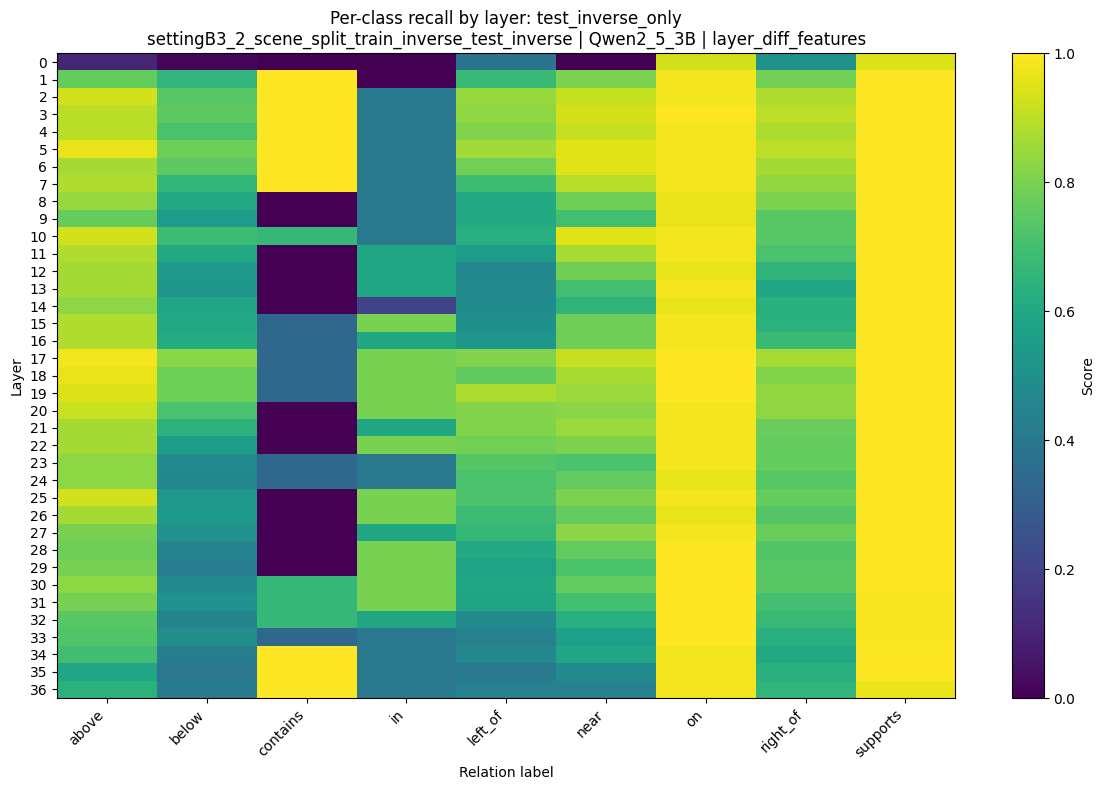

Saved: /content/step7_pilot4_settingB3_figures/step7_settingB3_2_scene_split_train_inverse_test_inverse_Qwen2_5_3B_layer_diff_features_test_inverse_only_recall_heatmap.png


In [7]:
# ============================================================
# Plot per-class recall heatmaps
# ============================================================

def plot_heatmap(df, title, output_path, vmin=0.0, vmax=1.0):
    plt.figure(figsize=(12, 8))

    im = plt.imshow(
        df.values,
        aspect="auto",
        interpolation="nearest",
        vmin=vmin,
        vmax=vmax,
    )

    plt.colorbar(im, label="Score")

    plt.xticks(
        ticks=np.arange(len(df.columns)),
        labels=df.columns,
        rotation=45,
        ha="right",
    )

    plt.yticks(
        ticks=np.arange(len(df.index)),
        labels=df.index,
    )

    plt.xlabel("Relation label")
    plt.ylabel("Layer")
    plt.title(title)
    plt.tight_layout()

    plt.savefig(output_path, dpi=200)
    plt.show()

    print("Saved:", output_path)


for subset_key in subset_keys:
    df = per_class_dfs[(subset_key, "recall")]

    fig_path = output_dir / f"step7_{experiment_name}_{model_tag}_{feature_key}_{subset_key}_recall_heatmap.png"

    plot_heatmap(
        df=df,
        title=(
            f"Per-class recall by layer: {subset_key}\n"
            f"{experiment_name} | {model_tag} | {feature_key}"
        ),
        output_path=fig_path,
    )

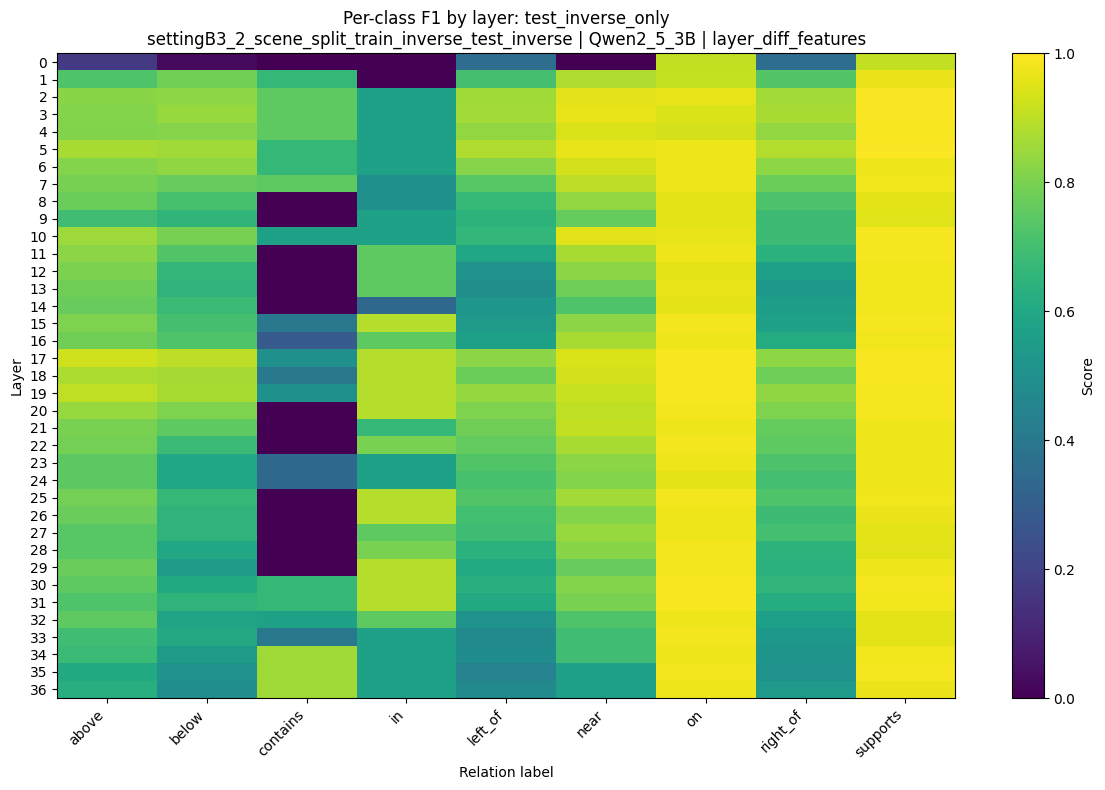

Saved: /content/step7_pilot4_settingB3_figures/step7_settingB3_2_scene_split_train_inverse_test_inverse_Qwen2_5_3B_layer_diff_features_test_inverse_only_f1_heatmap.png


In [8]:
# ============================================================
# Plot per-class F1 heatmaps
# ============================================================

for subset_key in subset_keys:
    df = per_class_dfs[(subset_key, "f1")]

    fig_path = output_dir / f"step7_{experiment_name}_{model_tag}_{feature_key}_{subset_key}_f1_heatmap.png"

    plot_heatmap(
        df=df,
        title=(
            f"Per-class F1 by layer: {subset_key}\n"
            f"{experiment_name} | {model_tag} | {feature_key}"
        ),
        output_path=fig_path,
    )

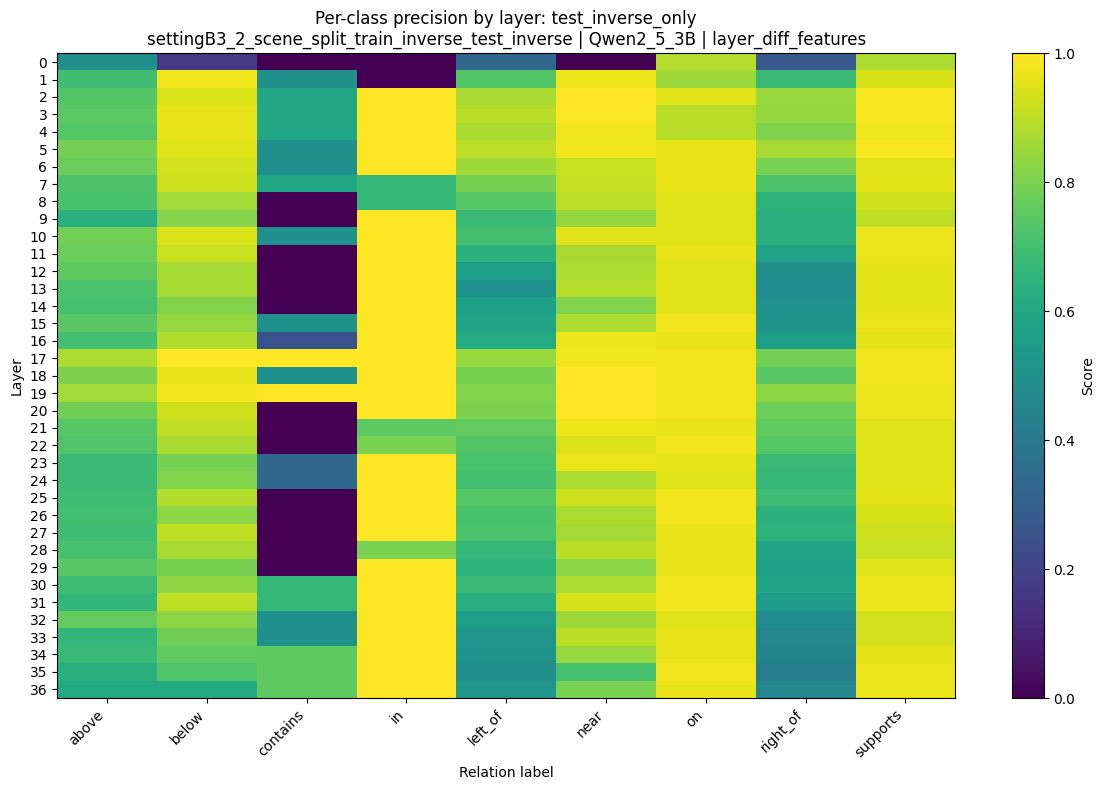

Saved: /content/step7_pilot4_settingB3_figures/step7_settingB3_2_scene_split_train_inverse_test_inverse_Qwen2_5_3B_layer_diff_features_test_inverse_only_precision_heatmap.png


In [9]:
# ============================================================
# Plot per-class precision heatmaps
# ============================================================

for subset_key in subset_keys:
    df = per_class_dfs[(subset_key, "precision")]

    fig_path = output_dir / f"step7_{experiment_name}_{model_tag}_{feature_key}_{subset_key}_precision_heatmap.png"

    plot_heatmap(
        df=df,
        title=(
            f"Per-class precision by layer: {subset_key}\n"
            f"{experiment_name} | {model_tag} | {feature_key}"
        ),
        output_path=fig_path,
    )

In [10]:
# ============================================================
# Find best layers for each subset
# ============================================================

def find_best_layer(data, subset_key, metric="macro_f1"):
    best_layer_result = max(
        data["results_by_layer"],
        key=lambda r: r[subset_key][metric],
    )

    return {
        "subset": subset_key,
        "metric": metric,
        "layer": int(best_layer_result["layer"]),
        "score": float(best_layer_result[subset_key][metric]),
        "accuracy": float(best_layer_result[subset_key]["accuracy"]),
        "macro_f1": float(best_layer_result[subset_key]["macro_f1"]),
    }


best_layer_rows = []

for subset_key in subset_keys:
    best_layer_rows.append(find_best_layer(data, subset_key, metric="macro_f1"))
    best_layer_rows.append(find_best_layer(data, subset_key, metric="accuracy"))

best_layer_df = pd.DataFrame(best_layer_rows)

best_layer_csv = output_dir / f"step7_{experiment_name}_{model_tag}_{feature_key}_best_layers.csv"
best_layer_df.to_csv(best_layer_csv, index=False)

print("Best layers:")
display(best_layer_df)

print("Saved:", best_layer_csv)

Best layers:


,subset,metric,layer,score,accuracy,macro_f1
0,test_inverse_only,macro_f1,17,0.86660,0.889552,0.866600
1,test_inverse_only,accuracy,5,0.90597,0.905970,0.851968


Saved: /content/step7_pilot4_settingB3_figures/step7_settingB3_2_scene_split_train_inverse_test_inverse_Qwen2_5_3B_layer_diff_features_best_layers.csv


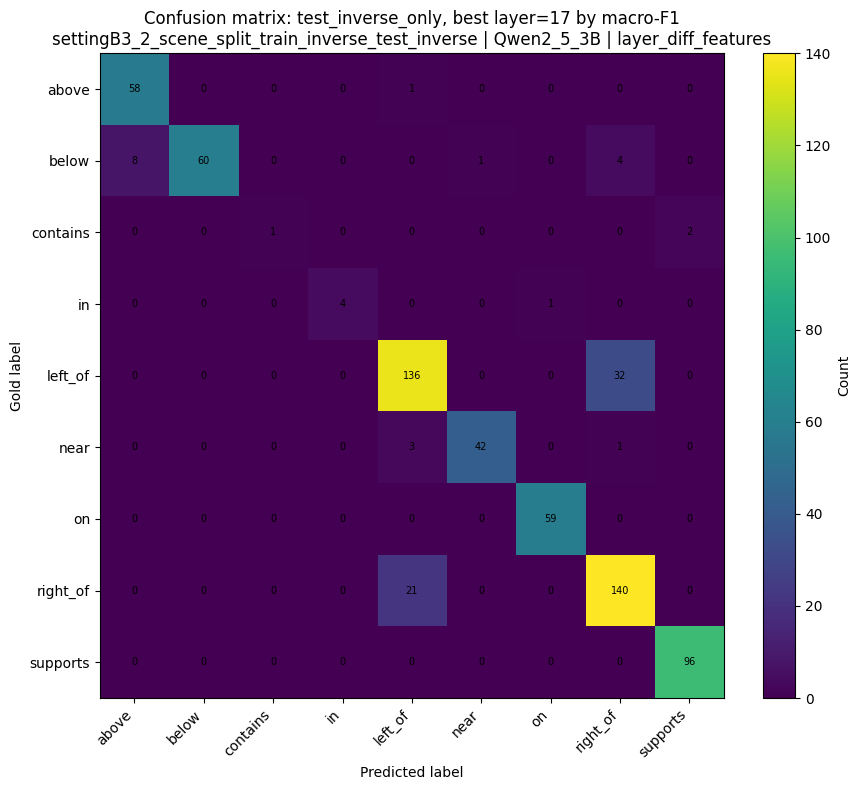

Saved: /content/step7_pilot4_settingB3_figures/step7_settingB3_2_scene_split_train_inverse_test_inverse_Qwen2_5_3B_layer_diff_features_test_inverse_only_best_layer17_confusion_count.png


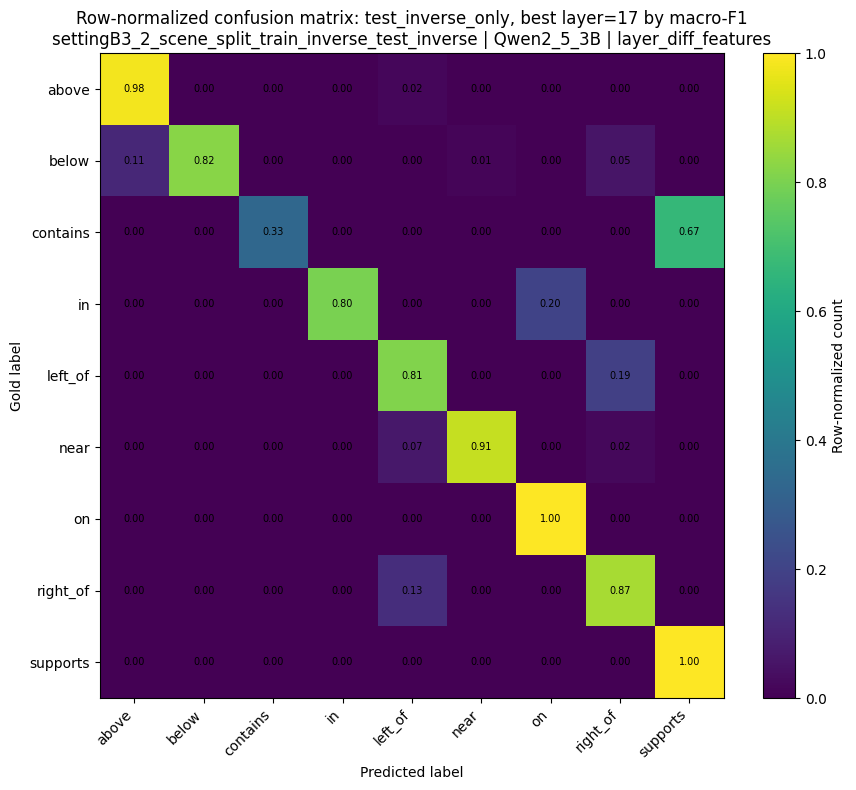

Saved: /content/step7_pilot4_settingB3_figures/step7_settingB3_2_scene_split_train_inverse_test_inverse_Qwen2_5_3B_layer_diff_features_test_inverse_only_best_layer17_confusion_normalized.png


In [11]:
# ============================================================
# Plot best-layer confusion matrices
# ============================================================

def get_layer_result(data, layer_id):
    for layer_result in data["results_by_layer"]:
        if int(layer_result["layer"]) == int(layer_id):
            return layer_result

    raise ValueError(f"Layer not found: {layer_id}")


def plot_confusion_matrix(cm, labels, title, output_path, normalize=False):
    cm = np.array(cm, dtype=float)

    if normalize:
        row_sums = cm.sum(axis=1, keepdims=True)
        cm_plot = np.divide(
            cm,
            row_sums,
            out=np.zeros_like(cm),
            where=row_sums != 0,
        )
        color_label = "Row-normalized count"
    else:
        cm_plot = cm
        color_label = "Count"

    plt.figure(figsize=(9, 8))

    im = plt.imshow(
        cm_plot,
        aspect="auto",
        interpolation="nearest",
    )

    plt.colorbar(im, label=color_label)

    plt.xticks(
        ticks=np.arange(len(labels)),
        labels=labels,
        rotation=45,
        ha="right",
    )

    plt.yticks(
        ticks=np.arange(len(labels)),
        labels=labels,
    )

    plt.xlabel("Predicted label")
    plt.ylabel("Gold label")
    plt.title(title)

    # Add values to cells
    for i in range(cm_plot.shape[0]):
        for j in range(cm_plot.shape[1]):
            if normalize:
                text = f"{cm_plot[i, j]:.2f}"
            else:
                text = str(int(cm[i, j]))

            plt.text(
                j,
                i,
                text,
                ha="center",
                va="center",
                fontsize=7,
            )

    plt.tight_layout()
    plt.savefig(output_path, dpi=200)
    plt.show()

    print("Saved:", output_path)


for subset_key in subset_keys:
    best_info = find_best_layer(data, subset_key, metric="macro_f1")
    best_layer = best_info["layer"]

    layer_result = get_layer_result(data, best_layer)

    cm = layer_result[subset_key]["confusion_matrix"]
    labels = layer_result[subset_key]["label_order"]

    fig_path_count = output_dir / (
        f"step7_{experiment_name}_{model_tag}_{feature_key}_"
        f"{subset_key}_best_layer{best_layer}_confusion_count.png"
    )

    plot_confusion_matrix(
        cm=cm,
        labels=labels,
        title=(
            f"Confusion matrix: {subset_key}, best layer={best_layer} by macro-F1\n"
            f"{experiment_name} | {model_tag} | {feature_key}"
        ),
        output_path=fig_path_count,
        normalize=False,
    )

    fig_path_norm = output_dir / (
        f"step7_{experiment_name}_{model_tag}_{feature_key}_"
        f"{subset_key}_best_layer{best_layer}_confusion_normalized.png"
    )

    plot_confusion_matrix(
        cm=cm,
        labels=labels,
        title=(
            f"Row-normalized confusion matrix: {subset_key}, best layer={best_layer} by macro-F1\n"
            f"{experiment_name} | {model_tag} | {feature_key}"
        ),
        output_path=fig_path_norm,
        normalize=True,
    )

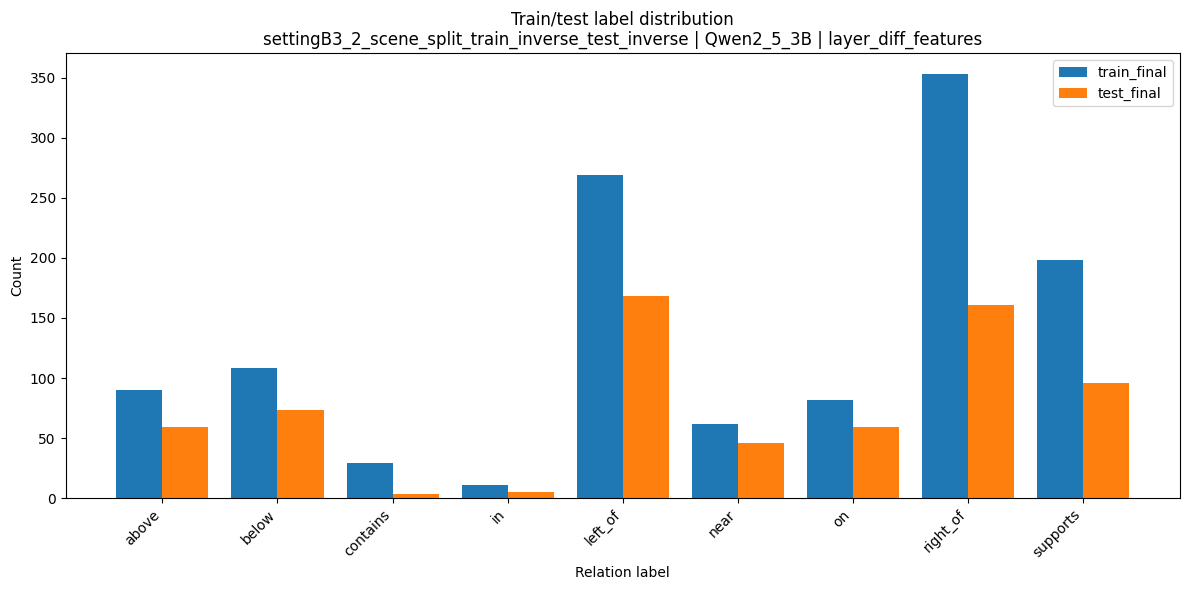

Saved: /content/step7_pilot4_settingB3_figures/step7_settingB3_2_scene_split_train_inverse_test_inverse_Qwen2_5_3B_layer_diff_features_train_test_label_distribution.png


In [12]:
# ============================================================
# Plot train/test label distribution
# ============================================================

def plot_label_distribution(count_dicts, labels, title, output_path):
    """
    count_dicts:
      list of (name, dict)
    """

    x = np.arange(len(labels))
    width = 0.8 / len(count_dicts)

    plt.figure(figsize=(12, 6))

    for i, (name, counts) in enumerate(count_dicts):
        values = [counts.get(label, 0) for label in labels]
        offset = (i - (len(count_dicts) - 1) / 2) * width

        plt.bar(
            x + offset,
            values,
            width=width,
            label=name,
        )

    plt.xticks(x, labels, rotation=45, ha="right")
    plt.ylabel("Count")
    plt.xlabel("Relation label")
    plt.title(title)
    plt.legend()
    plt.tight_layout()

    plt.savefig(output_path, dpi=200)
    plt.show()

    print("Saved:", output_path)


train_counts = scene_split_info.get("train_label_counts_final", {})
test_counts = scene_split_info.get("test_label_counts_final", {})

fig_path = output_dir / f"step7_{experiment_name}_{model_tag}_{feature_key}_train_test_label_distribution.png"

plot_label_distribution(
    count_dicts=[
        ("train_final", train_counts),
        ("test_final", test_counts),
    ],
    labels=label_order,
    title=(
        f"Train/test label distribution\n"
        f"{experiment_name} | {model_tag} | {feature_key}"
    ),
    output_path=fig_path,
)

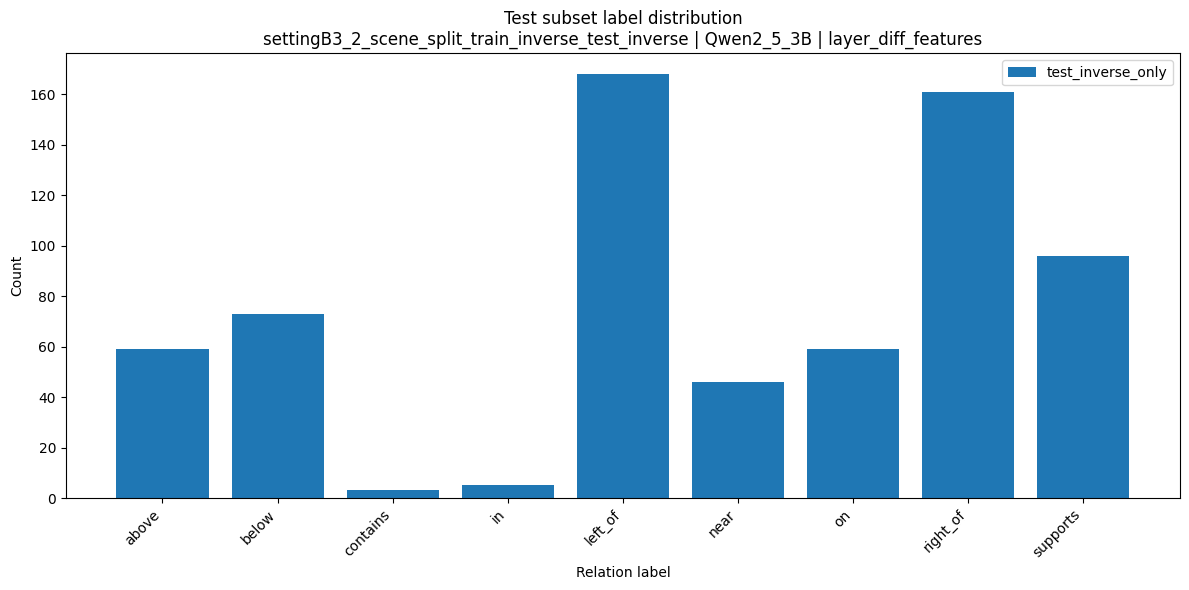

Saved: /content/step7_pilot4_settingB3_figures/step7_settingB3_2_scene_split_train_inverse_test_inverse_Qwen2_5_3B_layer_diff_features_test_subset_label_distribution.png


In [13]:
# ============================================================
# Plot test subset label distributions
# ============================================================

test_subset_count_dicts = []

for subset_key in subset_keys:
    counts = test_subset_summary.get(subset_key, {}).get("label_counts", {})
    test_subset_count_dicts.append((subset_key, counts))

fig_path = output_dir / f"step7_{experiment_name}_{model_tag}_{feature_key}_test_subset_label_distribution.png"

plot_label_distribution(
    count_dicts=test_subset_count_dicts,
    labels=label_order,
    title=(
        f"Test subset label distribution\n"
        f"{experiment_name} | {model_tag} | {feature_key}"
    ),
    output_path=fig_path,
)

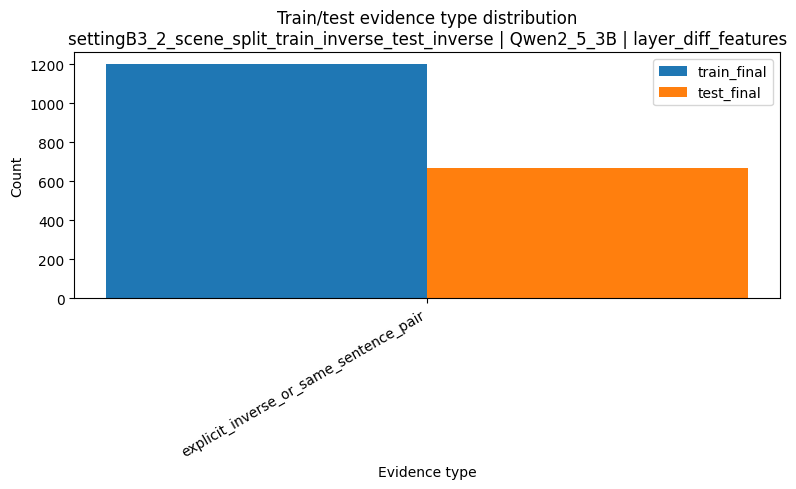

Saved: /content/step7_pilot4_settingB3_figures/step7_settingB3_2_scene_split_train_inverse_test_inverse_Qwen2_5_3B_layer_diff_features_train_test_evidence_type_distribution.png


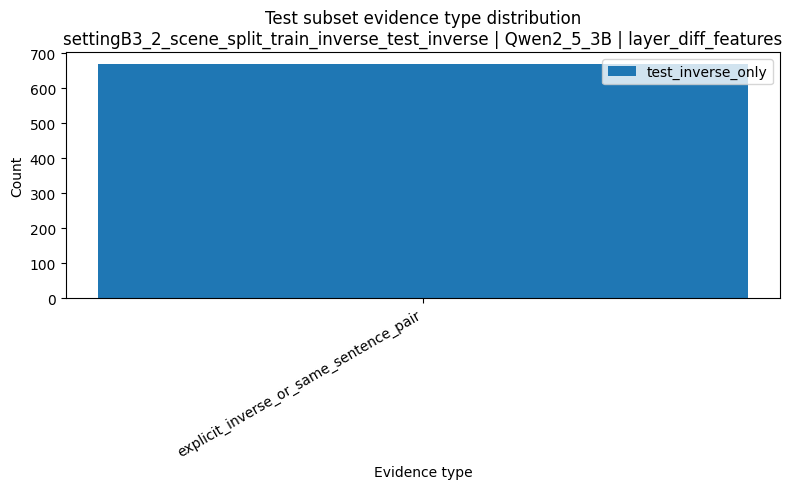

Saved: /content/step7_pilot4_settingB3_figures/step7_settingB3_2_scene_split_train_inverse_test_inverse_Qwen2_5_3B_layer_diff_features_test_subset_evidence_type_distribution.png


In [14]:
# ============================================================
# Plot evidence type distributions
# ============================================================

def plot_evidence_type_distribution(count_dicts, title, output_path):
    evidence_labels = sorted(
        set().union(*[set(counts.keys()) for _, counts in count_dicts])
    )

    if not evidence_labels:
        print("No evidence type counts found. Skipping:", output_path)
        return

    x = np.arange(len(evidence_labels))
    width = 0.8 / len(count_dicts)

    plt.figure(figsize=(8, 5))

    for i, (name, counts) in enumerate(count_dicts):
        values = [counts.get(label, 0) for label in evidence_labels]
        offset = (i - (len(count_dicts) - 1) / 2) * width

        plt.bar(
            x + offset,
            values,
            width=width,
            label=name,
        )

    plt.xticks(x, evidence_labels, rotation=30, ha="right")
    plt.ylabel("Count")
    plt.xlabel("Evidence type")
    plt.title(title)
    plt.legend()
    plt.tight_layout()

    plt.savefig(output_path, dpi=200)
    plt.show()

    print("Saved:", output_path)


# ------------------------------------------------------------
# Train/test final evidence type distribution
# ------------------------------------------------------------

train_evidence_counts = scene_split_info.get("train_evidence_type_counts_final", {})
test_evidence_counts = scene_split_info.get("test_evidence_type_counts_final", {})

fig_path = output_dir / f"step7_{experiment_name}_{model_tag}_{feature_key}_train_test_evidence_type_distribution.png"

plot_evidence_type_distribution(
    count_dicts=[
        ("train_final", train_evidence_counts),
        ("test_final", test_evidence_counts),
    ],
    title=(
        f"Train/test evidence type distribution\n"
        f"{experiment_name} | {model_tag} | {feature_key}"
    ),
    output_path=fig_path,
)


# ------------------------------------------------------------
# Test subset evidence type distribution
# ------------------------------------------------------------

test_subset_evidence_dicts = []

for subset_key in subset_keys:
    counts = test_subset_summary.get(subset_key, {}).get("evidence_type_counts", {})
    test_subset_evidence_dicts.append((subset_key, counts))

fig_path = output_dir / f"step7_{experiment_name}_{model_tag}_{feature_key}_test_subset_evidence_type_distribution.png"

plot_evidence_type_distribution(
    count_dicts=test_subset_evidence_dicts,
    title=(
        f"Test subset evidence type distribution\n"
        f"{experiment_name} | {model_tag} | {feature_key}"
    ),
    output_path=fig_path,
)

In [15]:
# ============================================================
# Save Step 7 summary JSON
# ============================================================

step7_summary = {
    "source_step6_json": str(json_path),
    "output_dir": str(output_dir),
    "experiment_name": experiment_name,
    "model_tag": model_tag,
    "feature_key": feature_key,
    "num_layers": num_layers,
    "label_order": label_order,
    "subset_keys": subset_keys,
    "best_layers": best_layer_df.to_dict(orient="records"),
    "scene_split_info": scene_split_info,
    "test_subset_summary": test_subset_summary,
}

summary_path = output_dir / f"step7_{experiment_name}_{model_tag}_{feature_key}_summary.json"

with open(summary_path, "w", encoding="utf-8") as f:
    json.dump(step7_summary, f, indent=2, ensure_ascii=False)

print("Saved Step 7 summary:")
print(summary_path)

Saved Step 7 summary:
/content/step7_pilot4_settingB3_figures/step7_settingB3_2_scene_split_train_inverse_test_inverse_Qwen2_5_3B_layer_diff_features_summary.json


In [16]:
# ============================================================
# Zip Step 7 outputs
# ============================================================

import shutil

zip_base = f"/content/step7_pilot4_{experiment_name}_{model_tag}_{feature_key}_figures"
zip_path = shutil.make_archive(
    base_name=zip_base,
    format="zip",
    root_dir=output_dir,
)

print("Created Step 7 output zip:")
print(zip_path)

Created Step 7 output zip:
/content/step7_pilot4_settingB3_2_scene_split_train_inverse_test_inverse_Qwen2_5_3B_layer_diff_features_figures.zip


In [17]:
# ============================================================
# Download Step 7 output zip
# ============================================================

from google.colab import files

files.download(zip_path)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>